In [1]:
# To run this in Google Colab, uncomment the following line
# !pip install geometric_kernels

# If you want to use a version of the library from a specific branch on GitHub,
# say, from the "devel" branch, uncomment the line below instead
# !pip install "git+https://github.com/geometric-kernels/GeometricKernels@devel"

# Matérn and Heat Kernels on HypercubeGraph
This notebook shows how define and evaluate kernels on the hypercube graph $C^d = \{0, 1\}^d$ for modeling data encoded as binary vectors with kernels that respect the geometry of the Hamming distance.

At the very end of the notebook we also show how to construct *approximate finite-dimensional feature maps* for the kernels on the hypercube graph and how to use these to efficiently sample the Gaussian processes $\mathrm{GP}(0, k)$.

**Note:** the points on the hypercube graph $C^d$ are boolean vectors of size $d$ (`array`s of the suitable backend).

We use the **numpy** backend here.

<!--TABLE OF CONTENTS-->
## Contents
- [**Basics**](#Basics)
  - [Defining a Space](#Defining-a-Space)
  - [Defining a Kernel](#Defining-a-Kernel)
  - [Evaluating Kernels on Random Inputs](#Evaluating-Kernels-on-Random-Inputs)
  - [Visualizing Kernels](#Visualizing-Kernels)
- [**Feature Maps and Sampling**](#Feature-Maps-and-Sampling)
  - [Defining a Feature Map](#Defining-a-Feature-Map)
  - [Efficient Sampling using Feature Maps](#Efficient-Sampling-using-Feature-Maps)
- [**Citation**](#Citation)

## Basics

In [2]:
# Import a backend, we use numpy in this example.
import numpy as np

# Import the geometric_kernels backend.
import geometric_kernels

# Note: if you are using a backend other than numpy,
# you _must_ uncomment one of the following lines
# import geometric_kernels.tensorflow
# import geometric_kernels.torch
# import geometric_kernels.jax

# Import a space and an appropriate kernel.
from geometric_kernels.spaces import HypercubeGraph
from geometric_kernels.kernels import MaternGeometricKernel

# We use networkx to visualize graphs
import networkx as nx

import matplotlib as mpl
import matplotlib.pyplot as plt

INFO (geometric_kernels): Numpy backend is enabled. To enable other backends, don't forget to `import geometric_kernels.*backend name*`.
INFO (geometric_kernels): We may be suppressing some logging of external libraries. To override the logging policy, call `logging.basicConfig`.


### Defining a Space

First we create a GeometricKernels `space` that corresponds to the 6-dimensional hypercube graph $C^6 = \{0, 1\}^6$.

In [3]:
hypercube_graph = HypercubeGraph(6)

### Defining a Kernel

First, we create a generic Matérn kernel.

To initialize `MaternGeometricKernel` you just need to provide a `Space` object, in our case this is the `hypercube_graph` we have just created above.

There is also an optional second parameter `num` which determines the order of approximation of the kernel (*number of levels*).
There is a sensible default value for each of the spaces in the library, so change it only if you know what you are doing.

A brief account on theory behind the kernels on the Hypecube space can be found on this [documentation page](https://geometric-kernels.github.io/GeometricKernels/theory/hypercube_graph.html).

In [4]:
kernel = MaternGeometricKernel(hypercube_graph)

To support JAX, our classes do not keep variables you might want to differentiate over in their state.
Instead, some methods take a `params` dictionary as input, returning its modified version.

The next line initializes the dictionary of kernel parameters `params` with some default values.

**Note:** our kernels do not provide the outputscale/variance parameter frequently used in Gaussian processes.
However, it is usually trivial to add it by multiplying the kernel by an (optimizable) constant.

In [5]:
params = kernel.init_params()
print('params:', params)

params: {'nu': array([inf]), 'lengthscale': array([1.])}


To define two different kernels, Matern-3/2 and Matern-∞ (aka heat, RBF, squared exponential, diffusion), we need two different versions of `params` we define below.

**Note:** like in the Euclidean or the manifold case, and unlike the general graph case, the $1/2, 3/2, 5/2$ are reasonable values of $\nu$.

In [6]:
params["lengthscale"] = np.array([2.0])
params_32  = params.copy()
params_inf = params.copy()
del params
params_32["nu"]  = np.array([3/2])

params_inf["nu"] = np.array([np.inf])

Now two kernels are *defined* and we proceed to evaluating both on a set of random inputs.

### Evaluating Kernels on Random Inputs

We start by sampling `3` (uniformly) random points on our graph.
An explicit `key` parameter is needed to support JAX as one of the backends.

In [7]:
key = np.random.RandomState(1234)

key, xs = hypercube_graph.random(key, 3)

print(xs, xs.dtype)

[[ True False  True False False  True]
 [ True False False False  True False]
 [False False  True False False  True]] bool


Now we evaluate the two kernel matrices.

In [8]:
kernel_mat_32  = kernel.K(params_32,  xs, xs)
kernel_mat_inf = kernel.K(params_inf, xs, xs)

Finally, we visualize these matrices using `imshow`.

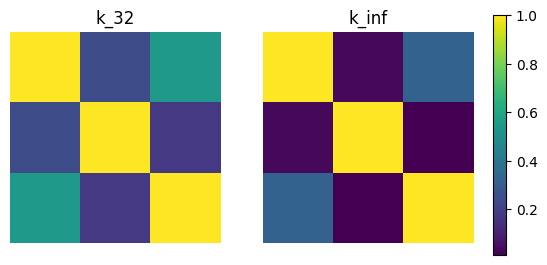

In [9]:
# find common range of values
minmin = np.min([np.min(kernel_mat_32), np.min(kernel_mat_inf)])
maxmax = np.max([np.max(kernel_mat_32), np.max(kernel_mat_inf)])

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2)
cmap = plt.get_cmap('viridis')

ax1.imshow(kernel_mat_32, vmin=minmin, vmax=maxmax, cmap=cmap)
ax1.set_title('k_32')
ax1.set_axis_off()

ax2.imshow(kernel_mat_inf, vmin=minmin, vmax=maxmax, cmap=cmap)
ax2.set_title('k_inf')
ax2.set_axis_off()

# add space for color bar
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.25, 0.02, 0.5])

# add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap,
                           norm=plt.Normalize(vmin=minmin, vmax=maxmax))
fig.colorbar(sm, cax=cbar_ax)

plt.show()

### Visualizing Kernels

Here we visualize $k_{\nu, \kappa}($ `base_point` $, x)$ for $x \in $ `other_points`.
We define `base_point` and `other_points` in the next cell.

In [10]:
import itertools
base_point = np.array([0]*6)[None, :] # choosing a fixed node for kernel visualization
other_points = np.array([list(i) for i in itertools.product([0, 1], repeat=6)])

The next cell evaluates $k_{\nu, \kappa}($ `base_point` $, x)$ for $x \in $ `other_points` for $\nu$ either $3/2$ or $\infty$.

In [11]:
values_32  = kernel.K(params_32,  base_point,
                              other_points).flatten()
values_inf = kernel.K(params_inf, base_point,
                              other_points).flatten()

We prepare the networkx graph for visualizing the space

In [12]:
# original code by moreka (https://github.com/moreka)
nx_graph = nx.hypercube_graph(6)
pos = {}
pos_list = [[3.18462, 1.34985], [3.46898, 2.21925], [3.0926, 0.433815], [2.21637, 1.30873], [2.28051, 0.928812], [2.86498, 2.26308], [2.29255, 1.64284], [2.64033, 2.62609], [2.26249, 0.620019], [1.22333, 1.6272], [1.30126, 1.27321], [1.8951, 2.67092], [3.07142, 3.07337], [2.8847, 1.2473], [1.83961, 2.30481], [1.90441, 1.92474], [2.24187, 3.47925], [1.91185, 1.59387], [0.847931, 2.64534], [0.921474, 2.26993], [2.64087, 1.90506], [2.23761, 0.0143973], [1.22294, 0.92365], [1.61988, 2.26091], [1.34731, 0.295391], [0.310627, 1.32606], [2.25335, 2.88409], [1.90784, 0.846041], [0.816332, 1.90238], [1.33814, 3.17037], [0.921199, 1.20639], [0., 2.22938], [2.55532, 2.28013], [2.16799, 0.321943], [1.5785, 2.6446], [1.24187, 0.594268], [2.14965, 3.18708], [1.85838, 1.23437], [1.28765, 3.48145], [0.835271, 1.58692], [1.57226, 1.90989], [1.27719, 0.], [0.5959, 2.24946], [0.418121, 0.397024], [1.22698, 2.87589], [0.848116, 0.849037], [0.413789, 3.08402], [0.00515571, 1.26256], [3.48101, 1.27272], [2.66405, 1.5921], [3.15933, 2.15967], [2.25775, 2.56393], [2.63577, 0.842368], [1.63869, 1.19036], [2.26401, 1.86592], [1.262, 2.18508], [2.56504, 1.22796], [1.58605, 1.5802], [2.17677, 2.23174], [1.20135, 2.56672], [1.59072, 0.82126], [0.611881, 1.2214], [1.19346, 1.85031], [0.295044, 2.14672]]
vert_list = [0, 32, 16, 8, 4, 2, 1, 33, 17, 9, 5, 3, 34, 18, 10, 6, 35, 19, 11, \
7, 36, 20, 12, 37, 21, 13, 38, 22, 14, 39, 23, 15, 40, 24, 41, 25, \
42, 26, 43, 27, 44, 28, 45, 29, 46, 30, 47, 31, 48, 49, 50, 51, 52, \
53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63]
nodes = list(nx_graph.nodes)
for i in range(len(nx_graph.nodes)):
    pos[nodes[vert_list[i]]] = pos_list[i]

Finally, we visualize the kernels

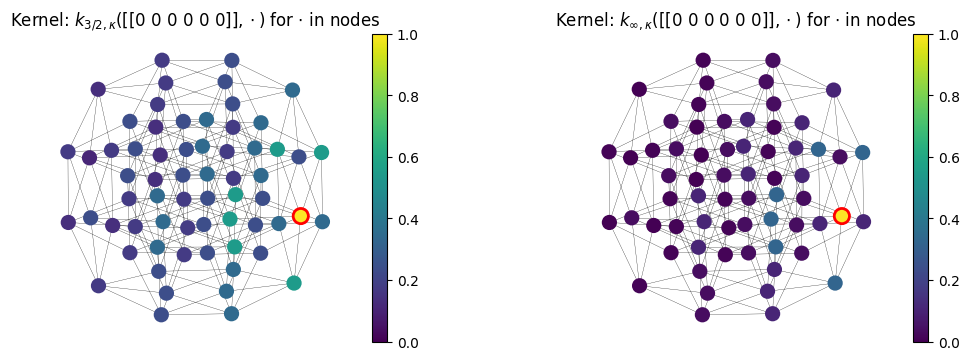

In [13]:
cmap = plt.get_cmap('viridis')

# Set the colorbar limits:
vmin = min(0.0, values_32.min(), values_inf.min())
vmax = max(1.0, values_32.max(), values_inf.max())


# Red outline for the base_point:
edgecolors = [(0, 0, 0, 0)]*nx_graph.number_of_nodes()
edgecolors[0] = (1, 0, 0, 1)

# Save graph layout so that graph appears the same in every plot
kwargs = {'pos': pos, 'node_size': 120, 'width': 0.2}


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.8, 4.))

# Plot kernel values 32
nx.draw(nx_graph, ax=ax1, cmap=cmap, node_color=values_32,
        vmin=vmin, vmax=vmax, edgecolors=edgecolors,
        linewidths=2.0, **kwargs)
sm = plt.cm.ScalarMappable(cmap=cmap,
                           norm=plt.Normalize(vmin=vmin, vmax=vmax))
cbar = plt.colorbar(sm, ax=ax1)
ax1.set_aspect(1)
ax1.set_title('Kernel: $k_{3/2, \kappa}($%s$, \cdot)$ for $\cdot$ in nodes' % str(base_point))

# Plot kernel values inf
nx.draw(nx_graph, ax=ax2, cmap=cmap, node_color=values_inf,
        vmin=vmin, vmax=vmax, edgecolors=edgecolors,
        linewidths=2.0, **kwargs)
sm = plt.cm.ScalarMappable(cmap=cmap,
                           norm=plt.Normalize(vmin=vmin, vmax=vmax))
cbar = plt.colorbar(sm, ax=ax2)
ax2.set_aspect(1)
ax2.set_title('Kernel: $k_{\infty, \kappa}($%s$, \cdot)$ for $\cdot$ in nodes' % str(base_point))


plt.show()

## Feature Maps and Sampling

Here we show how to get an approximate finite-dimensional feature map for heat and Matérn kernels on the hypecube $C^d$, i.e. such $\phi$ that
$$
k(x, x') \approx \langle \phi(x), \phi(x') \rangle_{\mathbb{R}^M}.
$$
This might be useful for speeding up computations.
We showcase this below by showing how to efficiently sample the Gaussian process $\mathrm{GP}(0, k)$.

For a brief theoretical introduction into feature maps, see this [documentation page](https://geometric-kernels.github.io/GeometricKernels/theory/feature_maps.html).

### Defining a Feature Map

The simplest way to get an approximate finite-dimensional feature map is to use the `default_feature_map` function from `geometric_kernels.kernels`.
For both hypercube and Hamming graphs, the default is `RandomPhaseFeatureMapHammingGraph`, which computes weights in the log domain. It returns random-phase features, avoiding explicit enumeration of all eigenfunctions.
The number of features is the number of selected spectral levels times the number of random phases. Below we use the kernel's levels and the default number of phases.
For a small hypercube, `DeterministicFeatureMapCompact` remains available explicitly.

In [14]:
from geometric_kernels.kernels import default_feature_map

feature_map = default_feature_map(kernel=kernel)

The resulting `feature_map` takes the array of inputs, kernel parameters, and a random `key`.
The optional `normalize` parameter defaults to `True` and normalizes each feature row to unit norm.

`feature_map` outputs a tuple containing the updated random key and the feature matrix.
Use the same initial random state when evaluating the same feature map at different inputs, or use `make_deterministic` from `geometric_kernels.utils.utils` to fix its randomness.

In the next cell, we evaluate the feature map at random points using `params_32` as kernel parameters.
We check the approximate identity $k(x, x') \approx \langle \phi(x), \phi(x') \rangle_{\mathbb{R}^M}$.

In [15]:
# xs are random points from above
key = np.random.RandomState(seed=1234)
key, embedding = feature_map(xs, params_32, key=key)

print('xs (shape = %s):\n%s' % (xs.shape, xs))
print('')
print('emedding (shape = %s):\n%s' % (embedding.shape, embedding))

kernel_mat_32  = kernel.K(params_32,  xs, xs)
kernel_mat_32_alt = np.matmul(embedding, embedding.T)

print('')
print('||k(xs, xs) - phi(xs) * phi(xs)^T|| =', np.linalg.norm(kernel_mat_32 - kernel_mat_32_alt))

xs (shape = (3, 6)):
[[ True False  True False False  True]
 [ True False False False  True False]
 [False False  True False False  True]]

emedding (shape = (3, 21000)):
[[ 0.00971383  0.0254809   0.03483511 ... -0.00097515  0.00139659
   0.00052213]
 [ 0.00955347  0.         -0.00685201 ...  0.00287715  0.
  -0.00051351]
 [ 0.00953122  0.01666794  0.01139342 ...  0.00287045  0.
  -0.00051232]]

||k(xs, xs) - phi(xs) * phi(xs)^T|| = 0.01134220000875446


### Efficient Sampling using Feature Maps

GeometricKernels provides a simple tool to efficiently sample (without incurring cubic costs) the Gaussian process $f \sim \mathrm{GP}(0, k)$, based on an approximate finite-dimensional feature map $\phi$.
The underlying machinery is briefly discussed in this [documentation page](https://geometric-kernels.github.io/GeometricKernels/theory/feature_maps.html).

The function `sampler` from `geometric_kernels.sampling` takes in a feature map and, optionally, the keyword argument `s` that specifies the number of samples to generate.
It returns a function we name `sample_paths`.

`sample_paths` operates much like `feature_map` above: it takes in the points where to evaluate the samples and kernel parameters.
Additionally, it takes in the keyword argument `key` that specifies randomness in the JAX style.
`sample_paths` returns a tuple.
Its first element is the updated `key`.
Its second element is an array containing the value of samples evaluated at the input points.

In [16]:
from geometric_kernels.sampling import sampler

sample_paths = sampler(feature_map, s=2)

# introduce random state for reproducibility (optional)
# `key` is jax's terminology
key = np.random.RandomState(seed=1234)

# new random state is returned along with the samples
key, samples = sample_paths(xs, params_32, key=key)

print('Two samples evaluated at the xs are:')
print(samples)

Two samples evaluated at the xs are:
[[ 109.45118372  -37.18577627]
 [ 248.17307823 -101.97313678]
 [ 160.51006775  181.20560366]]


#### Visualizing Samples
Here we visualize samples as functions on a graph.

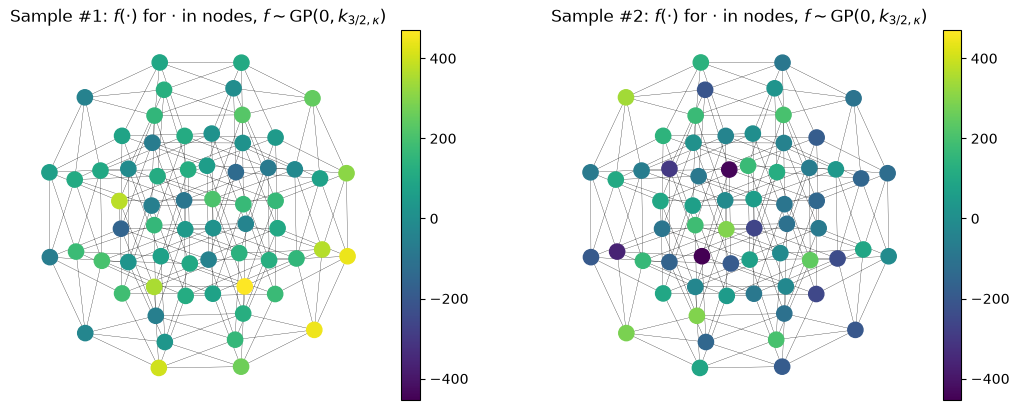

In [17]:
key = np.random.RandomState(seed=1234)
key, samples = sample_paths(other_points, params_32, key=key)

sample1 = samples[:, 0]
sample2 = samples[:, 1]

cmap = plt.get_cmap('viridis')

# Set the colorbar limits:
vmin = min(sample1.min(), sample2.min())
vmax = max(sample1.max(), sample2.max())

# Save graph layout so that graph appears the same in every plot
kwargs = {'pos': pos, 'node_size': 120, 'width': 0.2}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.8, 4.8))

# Plot sample #1
nx.draw(nx_graph, ax=ax1, cmap=cmap, node_color=sample1,
        vmin=vmin, vmax=vmax, **kwargs)
sm = plt.cm.ScalarMappable(cmap=cmap,
                           norm=plt.Normalize(vmin=vmin, vmax=vmax))
cbar = plt.colorbar(sm, ax=ax1)
ax1.set_title('Sample #1: $f(\cdot)$ for $\cdot$ in nodes, $f \sim \mathrm{GP}(0, k_{3/2, \kappa})$')


# Plot sample #2
nx.draw(nx_graph, ax=ax2, cmap=cmap, node_color=sample2,
        vmin=vmin, vmax=vmax, **kwargs)
sm = plt.cm.ScalarMappable(cmap=cmap,
                           norm=plt.Normalize(vmin=vmin, vmax=vmax))
cbar = plt.colorbar(sm, ax=ax2)
ax2.set_title('Sample #2: $f(\cdot)$ for $\cdot$ in nodes, $f \sim \mathrm{GP}(0, k_{3/2, \kappa})$')

plt.show()

## Citation

If you are using the HypercubeGraph space and GeometricKernels, please consider citing

```
@article{JMLR:v26:24-1185,
  author  = {Peter Mostowsky and Vincent Dutordoir and Iskander Azangulov and No{\'e}mie Jaquier and Michael John Hutchinson and Aditya Ravuri and Leonel Rozo and Alexander Terenin and Viacheslav Borovitskiy},
  title   = {The GeometricKernels Package: Heat and Mat{\'e}rn Kernels for Geometric Learning on Manifolds, Meshes, and Graphs},
  journal = {Journal of Machine Learning Research},
  year    = {2025},
  volume  = {26},
  number  = {276},
  pages   = {1--14},
  url     = {http://jmlr.org/papers/v26/24-1185.html}
}
```

```
@inproceedings{borovitskiy2023,
  title={Isotropic Gaussian Processes on Finite Spaces of Graphs},
  author={Borovitskiy, Viacheslav and Karimi, Mohammad Reza and Somnath, Vignesh Ram and Krause, Andreas},
  booktitle={International Conference on Artificial Intelligence and Statistics},
  year={2023},
}
```

```
@inproceedings{kondor2002,
    title={Diffusion Kernels on Graphs and Other Discrete Structures},
    author={Kondor, Risi Imre and Lafferty, John},
    booktitle={International Conference on Machine Learning},
    year={2002}
}
```